# Clustering & Empfehlungssystem mit Spotify-Daten

In dieser Übung wenden wir das *k-Means-Clustering* auf reale Musikdaten an und nutzen die gewonnenen Cluster, um ein einfaches Empfehlungssystem zu realisieren. Grundlage bildet der bereitgestellte Spotify-Datensatz. Der Datensatz enthält Songs mit verschiedenen numerischen Audio-Features (z.B. `danceability`, `energy`, `valence`, `tempo`, …) sowie Metadaten wie Songname und Künstler.

> **Wichtig**: Es werden keine Musikdateien verarbeitet – nur tabellarische Merkmalsdaten.

## Step 1 – Clustering vorbereiten und durchführen
1. Lese den Datensatz in ein DataFrame ein und verschaffe dir einen Überblick über die verfügbaren Spalten.
2. Wähle folgende Audio-Features für das Clustering aus.
````python
features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "acousticness"
]
````
3. Skaliere die ausgewählten Features mithilfes des `from sklearn.preprocessing import StandardScaler`.
4. Bestimme mithilfe der *Elbow-Methode* eine sinnvolle Anzahl von Clustern und begründe deine Entscheidung.
5. Führe das *k-Means-Clustering* durch und speichere die Cluster-Zugehörigkeit in einer neuen DataFrame-Spalte `cluster`.


## Step 2 – Cluster analysieren und interpretieren
Wie könnte man die Cluster-IDs durch "sprechende Namen" ersetzen? Fakt ist: Cluster sind keine Zufallsgruppen, k-Means trennt Songs nach hörbaren Eigenschaften (siehe unten, "Spotify Audio Features"). Es stellt sich die Frage, wie man das inhaltlich interpretieren kann. Berechne dazu für jedes Cluster die durchschnittlichen Feature-Werte und analysiere, welche musikalischen Eigenschaften für ein Cluster typisch sind. Technisch lässt sich das einfach umsetzen, indem man die Daten nach der Cluster-ID gruppiert (`groupby`) und anschließend die Mittelwerte der Features berechnet (`mean`). Auf Basis dieser Ergebnisse können die Cluster anschließend sinnvoll benannt werden. Mögliches Ergebnis:

<table style="border-collapse: collapse; border: none;">
  <thead>
    <tr>
      <th style="border: none; padding: 6px 10px; text-align: left;">cluster</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">danceability</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">energy</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">valence</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">tempo</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">loudness</th>
      <th style="border: none; padding: 6px 10px; text-align: left;">acousticness</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: none; padding: 6px 10px;">0</td>
      <td style="border: none; padding: 6px 10px;">0.328877</td>
      <td style="border: none; padding: 6px 10px;">0.130540</td>
      <td style="border: none; padding: 6px 10px;">0.202757</td>
      <td style="border: none; padding: 6px 10px;">101.348505</td>
      <td style="border: none; padding: 6px 10px;">-20.285603</td>
      <td style="border: none; padding: 6px 10px;">0.910890</td>
    </tr>
    <tr>
      <td style="border: none; padding: 6px 10px;">1</td>
      <td style="border: none; padding: 6px 10px;">0.692207</td>
      <td style="border: none; padding: 6px 10px;">0.682728</td>
      <td style="border: none; padding: 6px 10px;">0.723080</td>
      <td style="border: none; padding: 6px 10px;">112.218747</td>
      <td style="border: none; padding: 6px 10px;">-7.930148</td>
      <td style="border: none; padding: 6px 10px;">0.209092</td>
    </tr>
    <tr>
      <td style="border: none; padding: 6px 10px;">2</td>
      <td style="border: none; padding: 6px 10px;">0.613275</td>
      <td style="border: none; padding: 6px 10px;">0.328898</td>
      <td style="border: none; padding: 6px 10px;">0.697586</td>
      <td style="border: none; padding: 6px 10px;">124.636584</td>
      <td style="border: none; padding: 6px 10px;">-13.670161</td>
      <td style="border: none; padding: 6px 10px;">0.775998</td>
    </tr>
    <tr>
      <td style="border: none; padding: 6px 10px;">3</td>
      <td style="border: none; padding: 6px 10px;">0.452503</td>
      <td style="border: none; padding: 6px 10px;">0.754799</td>
      <td style="border: none; padding: 6px 10px;">0.458293</td>
      <td style="border: none; padding: 6px 10px;">143.121093</td>
      <td style="border: none; padding: 6px 10px;">-7.166245</td>
      <td style="border: none; padding: 6px 10px;">0.131068</td>
    </tr>
    <tr>
      <td style="border: none; padding: 6px 10px;">4</td>
      <td style="border: none; padding: 6px 10px;">0.467195</td>
      <td style="border: none; padding: 6px 10px;">0.352799</td>
      <td style="border: none; padding: 6px 10px;">0.359778</td>
      <td style="border: none; padding: 6px 10px;">97.883068</td>
      <td style="border: none; padding: 6px 10px;">-11.756958</td>
      <td style="border: none; padding: 6px 10px;">0.684595</td>
    </tr>
  </tbody>
</table>



### Spotify Audio Features
Nachfolgende Taxonomie soll als Interpretationshilfe für die Analyse von Clustern dienen. Sie beschreibt, was die einzelnen Features aussagen und wie typische Werte zu verstehen sind.

#### 1) danceability – Tanzbarkeit

**Beschreibung:**
Beschreibt, wie gut sich ein Song zum Tanzen eignet. Berücksichtigt u.a. Rhythmus-Stabilität, Beat und Tempo.

**Wertebereich:**
0.0 – 1.0

| Wertebereich | Interpretation |
|--------------|----------------|
| 0.0 – 0.3 | kaum tanzbar |
| 0.3 – 0.6 | mäßig tanzbar |
| 0.6 – 1.0 | sehr tanzbar |

**Typische Assoziationen:**
Groove, Pop, Dance, Disco, Club


#### 2) energy – Energie / Intensität

**Beschreibung:**
Misst die wahrgenommene Intensität und „Druck“ eines Songs. Bezieht Lautstärke, Dynamik und Verzerrung ein.

**Wertebereich:**
0.0 – 1.0

| Wertebereich | Interpretation |
|--------------|----------------|
| 0.0 – 0.3 | sehr ruhig |
| 0.3 – 0.6 | mittlere Energie |
| 0.6 – 1.0 | sehr energiereich |

**Typische Assoziationen:**
Rock, EDM, Workout, Party

#### 3) valence – Emotionale Stimmung

**Beschreibung:**
Beschreibt die emotionale Grundstimmung eines Songs – von traurig bis fröhlich.

**Wertebereich:**
0.0 – 1.0

| Wertebereich | Interpretation |
|--------------|----------------|
| 0.0 – 0.3 | traurig / melancholisch |
| 0.3 – 0.6 | neutral / gemischt |
| 0.6 – 1.0 | fröhlich / positiv |

**Typische Assoziationen:**
Happy, Sad, Sommermusik, melancholisch


#### 4) tempo – Geschwindigkeit

**Beschreibung:**
Gibt die Geschwindigkeit eines Songs in *Beats per Minute* (BPM) an.

**Wertebereich:**
ca. 60 – 200 BPM

| Tempo (BPM) | Interpretation |
|-------------|----------------|
| < 90 | langsam |
| 90 – 120 | moderat |
| 120 – 140 | schnell |
| > 140 | sehr schnell |

**Typische Assoziationen:**
Balladen (langsam), Pop (moderat), EDM/Techno (schnell)

#### 5) loudness – Lautstärke

**Beschreibung:**
Durchschnittliche Lautheit eines Songs in *dBFS* (Dezibel Full Scale).
Alle Werte sind negativ – je näher an 0, desto lauter.

**Wertebereich:**
ca. −25 bis 0 dBFS

| Loudness (dBFS) | Interpretation |
|-----------------|----------------|
| < −18 | sehr leise |
| −18 bis −14 | leise |
| −14 bis −10 | mittlere Lautstärke |
| −10 bis −6 | laut |
| > −6 | sehr laut |

**Typische Assoziationen:**
Akustisch (leise), Pop/Rock (laut), EDM (sehr laut)


#### 6) acousticness – Akustischer Charakter

**Beschreibung:**
Gibt an, wie wahrscheinlich es ist, dass ein Song akustisch (nicht elektronisch) ist.

**Wertebereich:**
0.0 – 1.0

| Wertebereich | Interpretation |
|--------------|----------------|
| 0.0 – 0.3 | stark elektronisch |
| 0.3 – 0.6 | gemischt |
| 0.6 – 1.0 | stark akustisch |

**Typische Assoziationen:**
Unplugged, Folk, Singer-Songwriter


> **Hinweis**: Die angegebenen Grenzen sind nur grobe Orientierungshilfen. Diese wurden nicht exakt berechnet.


## Step 3 – Empfehlungssystem implementieren

Implementiert eine Funktion, die auf Basis des Clusterings für einen gegebenen Song ähnliche Songs ermittelt und - ganz wichtig - empfiehlt.

### Vorgabe

```python
def recommend_songs(song_name, df, n=5):
    ...
````
Im Detail:

| Parameter   | Typ                | Beschreibung |
|------------|--------------------|--------------|
| `song_name` | `str`              | Name des Songs, für den ähnliche Songs empfohlen werden sollen. Der Name muss im Datensatz vorhanden sein. |
| `df`        | `pandas.DataFrame` | DataFrame mit den Spotify-Daten. Muss mindestens die Spalten `name`, `artists` und `cluster` enthalten. |
| `n`         | `int` (optional)   | Anzahl der gewünschten Empfehlungen. Standardwert: `5`. |


Was die Funktion `recommend_songs` Schritt für Schritt ausführt, ist im folgenden Flowchart-Diagramm dargestellt. Kopiere den *PlantUML*-Code in den Online-Editor:: https://plantuml.online/

````uml
@startuml recommend_songs_activity
title Ablaufdiagramm: recommend_songs(song_name, df, n)

start

:Aufruf der Funktion\nrecommend_songs(song_name, df, n);

if (song_name im Datensatz?) then (ja)
  :Zeile mit dem gesuchten Song aus df herausfiltern\n(name == song_name);
  :Cluster-Nummer dieses Songs auslesen;
  :Alle Songs mit gleichem Cluster auswählen;
  :Zufällig n-viele Songs aus diesem Cluster auswählen;
  :Name und Künstler der n-vielen Songs zurückgeben;
else (nein)
  :Fehlermeldung ausgeben;
endif

stop
@enduml
````

In [1]:
import pandas as pd

df = pd.read_csv("spotify-data.csv")
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


In [3]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features].dropna()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

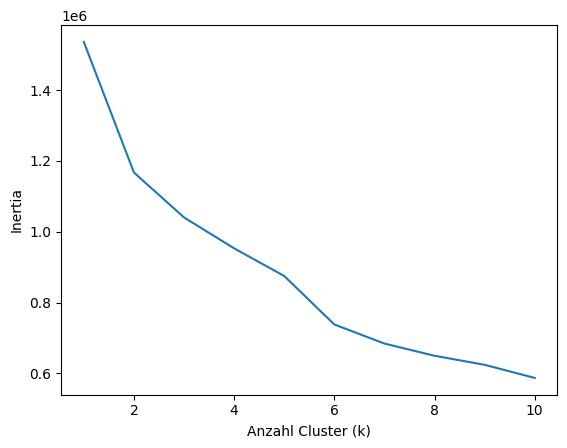

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Inertia")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)


In [7]:
cluster_means = df.groupby("cluster")[features].mean()
cluster_means


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.395660,0.215374,-18.470264,0.055607,0.889995,0.805809,0.176910,0.354266,105.109277
1,0.463127,0.746045,-7.210127,0.081547,0.153362,0.091822,0.292471,0.466112,135.535755
2,0.501808,0.261726,-14.337094,0.148266,0.776586,0.033303,0.211246,0.435145,109.317710
3,0.686257,0.624738,-8.626664,0.082171,0.314816,0.061487,0.152830,0.738330,116.118368


In [8]:
def recommend(song_name, n=5):
    song = df[df["name"] == song_name]

    if song.empty:
        return "Song nicht gefunden."

    cluster_id = song["cluster"].values[0]

    recommendations = df[
        (df["cluster"] == cluster_id) &
        (df["name"] != song_name)
    ].sample(n)

    return recommendations[["name", "artists"]]


In [9]:
recommend("Blinding Lights", 5)

,name,artists
36757,Kiss Me Slowly,['Parachute']
82798,Like A Rolling Stone - Live At The Academy Of ...,"['The Band', 'Bob Dylan', 'Dan Gellert']"
157819,I Can't Quit You Baby - Take 3,['Otis Rush']
73667,The Gunslinger,['Shooter Jennings']
52409,Where Have All the Cowboys Gone?,['Paula Cole']
